Importação das bibliotecas

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Carregamento dos dados

In [15]:
# Diretório do notebook
notebook_dir = os.getcwd()
print("Notebook está em:", notebook_dir)

# Caminho para o CSV subindo dois níveis
file_path = os.path.join(notebook_dir, "..", "..", "data", "raw", "ITUB4.SA_raw.csv")

# Lê o CSV
df = pd.read_csv(file_path)
df = df.drop(columns=["Unnamed: 0"])

#Trata datahora para data, já que a hora está zerada para todos os registros
df['Date'] = pd.to_datetime(df['Date']).dt.date

df.head()

Notebook está em: c:\Users\alice\OneDrive\Área de Trabalho\tech_challenge_4\scripts\data_exploration


,Date,Ticker,Close,High,Low,Open,Volume
0,2018-01-02,ITUB4.SA,15.464824,15.464824,15.084195,15.084195,18865469
1,2018-01-03,ITUB4.SA,15.570539,15.626930,15.355555,15.471858,25261028
2,2018-01-04,ITUB4.SA,15.894783,15.965270,15.595214,15.595214,26311149
3,2018-01-05,ITUB4.SA,15.940612,15.972331,15.718578,15.901845,17807870
4,2018-01-08,ITUB4.SA,15.887738,15.972323,15.782009,15.880689,14398333


Exploração de dados

In [16]:
df.describe()

,Close,High,Low,Open,Volume
count,2074.000000,2074.000000,2074.000000,2074.000000,2.074000e+03
mean,21.813026,22.069377,21.563856,21.818172,3.231508e+07
std,6.998263,7.037201,6.953667,6.996069,1.661099e+07
min,12.908777,13.521483,12.581653,13.423312,0.000000e+00
25%,17.268758,17.532703,17.040170,17.301051,2.070788e+07
50%,19.610819,19.885135,19.386335,19.616491,2.841094e+07
75%,24.065062,24.280571,23.856207,24.091247,4.000779e+07
max,48.905392,49.202568,48.142637,48.588397,1.820390e+08


In [17]:
print(f"Há dados de {min(df["Date"])} a {max(df["Date"])}.")

Há dados de 2018-01-02 a 2026-05-08.


Não há valores vazios:

In [18]:
# Cria tabela de valores faltantes
missing_values = pd.DataFrame({
    'coluna': df.columns,
    'valores_vazios': df.isnull().sum(),
    'percentual_vazio': df.isnull().mean() * 100
})

# Ordena pela coluna mais vazia (opcional)
missing_values = missing_values.sort_values(by='valores_vazios', ascending=False)

missing_values

,coluna,valores_vazios,percentual_vazio
Date,Date,0,0.0
Ticker,Ticker,0,0.0
Close,Close,0,0.0
High,High,0,0.0
Low,Low,0,0.0
Open,Open,0,0.0
Volume,Volume,0,0.0


Visualização temporal

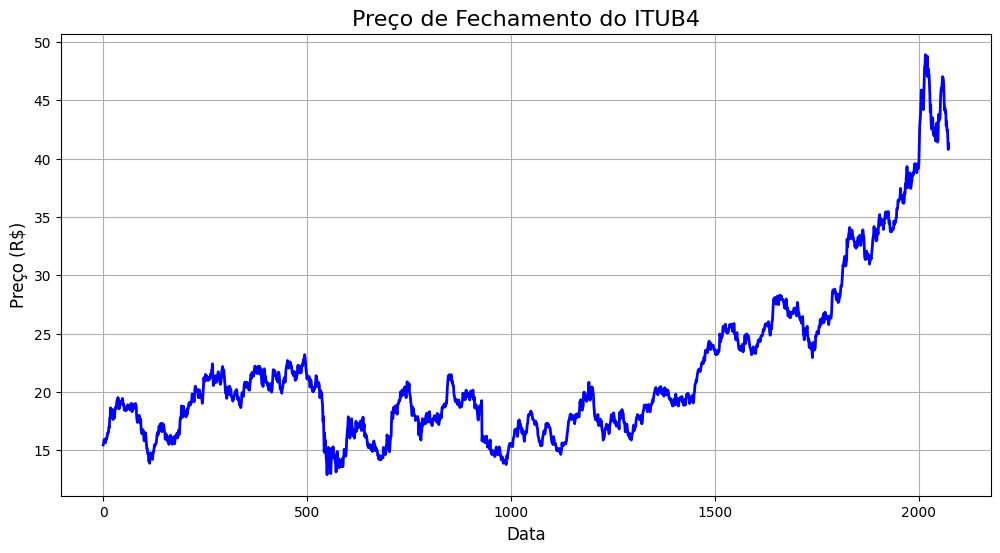

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], color='blue', linewidth=2)
plt.title("Preço de Fechamento do ITUB4", fontsize=16)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Preço (R$)", fontsize=12)
plt.grid(True)
plt.show()